In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from RNNs_utils import *
from RNNs_model import *

import warnings
warnings.filterwarnings("ignore")

In [2]:
daily = pd.read_csv('../Datasets/paper_data/Boulder_Daily.csv')
daily.drop(columns={'Unnamed: 0','Date', 'Year'}, inplace=True)
daily.head()

,Energy__kWh_,Weekday,Month,Minimum T,Maximum T,Snow,Precipitation
0,6.504,Monday,January,12,30,0.0,0.0
1,17.527,Tuesday,January,24,92,0.0,0.0
2,11.227,Wednesday,January,60,150,0.0,0.0
3,49.748,Thursday,January,144,312,0.0,0.0
4,2.956,Friday,January,50,124,0.0,0.0


In [3]:
daily.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1668 entries, 0 to 1667
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Energy__kWh_   1668 non-null   float64
 1   Weekday        1668 non-null   object 
 2   Month          1668 non-null   object 
 3   Minimum T      1668 non-null   int64  
 4   Maximum T      1668 non-null   int64  
 5   Snow           1668 non-null   float64
 6   Precipitation  1668 non-null   float64
dtypes: float64(3), int64(2), object(2)
memory usage: 91.3+ KB


## **Preprocessing**

    Divided the dataset into training, testing, and validation datasets according to 0.70, 0.20, and 0.10, respectively.

In [4]:
train_daily, val_daily, test_daily = split_dataset(daily, train_ratio=0.7, val_ratio=0.2)

Training split ratio:   0.7
Validation split ratio: 0.2
Testing split ratio:    0.101

Shapes of the datasets:
(1167, 7) (333, 7) (168, 7)


    One Hot Encode

In [5]:
# List of all months and weekdays
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# One-hot encode 'Month' and 'Weekday' columns for train_daily and drop 'Month' and 'Weekday' columns after one-hot encoding
train_daily = one_hot_encode(train_daily, months, weekdays)
train_daily.drop(columns=['Month', 'Weekday'], inplace=True)

# One-hot encode 'Month' and 'Weekday' columns for val_daily and drop 'Month' and 'Weekday' columns after one-hot encoding
val_daily = one_hot_encode(val_daily, months, weekdays)
val_daily.drop(columns=['Month', 'Weekday'], inplace=True)

# One-hot encode 'Month' and 'Weekday' columns for test_daily and drop 'Month' and 'Weekday' columns after one-hot encoding
test_daily = one_hot_encode(test_daily, months, weekdays)
test_daily.drop(columns=['Month', 'Weekday'], inplace=True)

In [6]:
train_daily.columns

Index(['Energy__kWh_', 'Minimum T', 'Maximum T', 'Snow', 'Precipitation',
       'January', 'February', 'March', 'April', 'May', 'June', 'July',
       'August', 'September', 'October', 'November', 'December', 'Monday',
       'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
      dtype='object')

    Create sequences for the RNNs model

In [7]:
# Define the time window size
sequence_length = 30

# Create sequences for training data
X_train, Y_train = create_sequences(train_daily, sequence_length, 'Energy__kWh_', step=1)
# Create sequences for validation data
X_val, Y_val = create_sequences(val_daily, sequence_length, 'Energy__kWh_', step=1)
# Create sequences for test data
X_test, Y_test = create_sequences(test_daily, sequence_length, 'Energy__kWh_', step=1)

Dataset split into sequences:
Sequences shape: (1137, 30, 24)
Targets shape: (1137,)

Dataset split into sequences:
Sequences shape: (303, 30, 24)
Targets shape: (303,)

Dataset split into sequences:
Sequences shape: (138, 30, 24)
Targets shape: (138,)



**Scalling the Numerical columns**

    Scaling the X_train and Y_train

In [8]:
# We scale also with MinMaxScaler this input columns ['Energy__kWh_', 'Maximum T', 'Minimum T', 'Precipitation', 'Snow']
numerical_D = len(['Energy__kWh_', 'Maximum T', 'Minimum T', 'Precipitation', 'Snow'])

# ----------------------
#    SCALE THE X_train
# ----------------------

# Initialize the input scaler
inputs_scaler = MinMaxScaler()
# Extract the first 5 columns from X_train
X_train_subset = X_train[:, :, :numerical_D]
# Reshape the subset to 2D array
X_train_subset_2d = X_train_subset.reshape(-1, numerical_D)
# Fit the scaler on the subset and transform it. Also reshape the scaled subset back to the original shape
x_scaler = inputs_scaler.fit_transform(X_train_subset_2d).reshape(X_train.shape[0], X_train.shape[1], numerical_D)
# Combine the scaled subset with the remaining columns of X_train
X_train_scaled = np.concatenate([x_scaler, X_train[:, :, numerical_D:]], axis=-1)

# ----------------------
#    SCALE THE Y_train
# ----------------------

# Initialize the output scaler
output_scaler = MinMaxScaler()
# Reshape the subset to 2D array
Y_train_reshaped = Y_train.reshape(-1,1)
Y_train_scaled = output_scaler.fit_transform(Y_train_reshaped)

    Scaling the X_val, X_test and Y_val, Y_test accord to X_train MinMaxScaler

In [9]:
def scale_data_with_fitted_scaler(inputs_scaler, output_scaler, X, Y, numerical_D):
    # ----------------------
    #    SCALE THE X_array with the fitted scaler of X_train
    # ----------------------
    # Extract the first 5 columns from X
    X_subset = X[:, :, :numerical_D].reshape(-1, numerical_D)
    # Scaling 
    X_scaled_subset = inputs_scaler.transform(X_subset).reshape(X.shape[0], X.shape[1], numerical_D)
    # Combine the scaled subset with the remaining columns of X
    X_scaled = np.concatenate([X_scaled_subset, X[:, :, numerical_D:]], axis=-1)

    # ----------------------
    #    SCALE THE Y_array with the fitted scaler of X_train
    # ----------------------

    # Reshape the subset of Y to 2D array
    Y_reshaped = Y.reshape(-1,1)
    # Use the previously fitted scaler to transform the Y_reshaped
    Y_scaled = output_scaler.transform(Y_reshaped)

    return X_scaled, Y_scaled

X_val_scaled, Y_val_scaled = scale_data_with_fitted_scaler(inputs_scaler, output_scaler, X_val, Y_val, numerical_D)
X_test_scaled, Y_test_scaled = scale_data_with_fitted_scaler(inputs_scaler, output_scaler, X_test, Y_test, numerical_D)

print('Train Dataset:')
print("scaled X_train shape:", X_train_scaled.shape)
print("scaled Y_train shape:", Y_train_scaled.shape)

print('\nValidation Dataset:')
print("scaled X_val shape:", X_val_scaled.shape)
print("scaled Y_val shape:", Y_val_scaled.shape)

print('\nTest Dataset:')
print("scaled X_test shape:", X_test_scaled.shape)
print("scaled Y_test shape:", Y_test_scaled.shape)

Train Dataset:
scaled X_train shape: (1137, 30, 24)
scaled Y_train shape: (1137, 1)

Validation Dataset:
scaled X_val shape: (303, 30, 24)
scaled Y_val shape: (303, 1)

Test Dataset:
scaled X_test shape: (138, 30, 24)
scaled Y_test shape: (138, 1)


In [10]:
X_train_scaled.max(), X_val_scaled.max(), X_test_scaled.max()

(1.0000000000000002, 1.3309169989126497, 1.7299746284885833)

In [11]:
X_train_scaled.min(), X_val_scaled.min(), X_test_scaled.min()

(0.0, -0.019801980198019806, 0.0)

    Create the RNNs Models

In [12]:
# Define the input shape for the models ||  input_shape = (sequence_length, num_features)
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2])

# Define common parameters
simple_rnn_num_layers, lstm_num_layers, bi_lstm_num_layers, gru_num_layers = 3, 6, 3, 3
simple_rnn_num_units, lstm_num_units, bi_lstm_num_units, gru_num_units = 64, 128, 64, 64
recurrent_activation_function = 'relu'
# Define the default regularation l2=0.01  ||  If we want we can train the model without regularations. (regularization = 0)
kernel_regularization = 0.01
recurrent_regularization = 0
bias_regularization = 0
dropout_rate = 0
recurrent_dropout_rate = 0.1

In [13]:
# -------------------
# Build the Models
# -------------------

# Create Simple RNN model
simple_rnn = RnnModel('SimpleRNN', input_shape, simple_rnn_num_layers, simple_rnn_num_units, recurrent_activation_function,
                      recurrent_regularization, kernel_regularization, bias_regularization,
                      dropout_rate, recurrent_dropout_rate)

# Create LSTM model
lstm = RnnModel('LSTM', input_shape, lstm_num_layers, lstm_num_units, recurrent_activation_function,
                recurrent_regularization, kernel_regularization, bias_regularization,
                dropout_rate, recurrent_dropout_rate)

# Create GRU model
gru = RnnModel('GRU', input_shape, gru_num_layers, gru_num_units, recurrent_activation_function,
               recurrent_regularization, kernel_regularization, bias_regularization,
               dropout_rate, recurrent_dropout_rate)

# Create Bi-LSTM model
bi_lstm = RnnModel('Bi-LSTM', input_shape, bi_lstm_num_layers, bi_lstm_num_units, recurrent_activation_function,
                   recurrent_regularization, kernel_regularization, bias_regularization,
                   dropout_rate, recurrent_dropout_rate)


print("Models created successfully.")

Models created successfully.


In [14]:
# Print summaries of the configurations
print("LSTM Summary:")
lstm.summary()
print()

print("Simple RNN Summary:")
simple_rnn.summary()
print()

print("Bi-LSTM Summary:")
bi_lstm.summary()
print()

print("GRU Summary:")
gru.summary()

LSTM Summary:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30, 128)           78336     
                                                                 
 lstm_1 (LSTM)               (None, 30, 128)           131584    
                                                                 
 lstm_2 (LSTM)               (None, 30, 128)           131584    
                                                                 
 lstm_3 (LSTM)               (None, 30, 128)           131584    
                                                                 
 lstm_4 (LSTM)               (None, 30, 128)           131584    
                                                                 
 lstm_5 (LSTM)               (None, 128)               131584    
                                                                 
 dense_1 (Dense)             (None, 1)  

    Compile the models

In [15]:
# Define the learning rate for Adam optimizer
learning_rate = 0.001

# Define a dictionary to map model names to their corresponding model objects
rnn_models = {
    'simple_rnn': simple_rnn,
    'lstm': lstm,
    'gru': gru,
    'bi_lstm': bi_lstm
}

# Compile each RNN model
for model_name, model in rnn_models.items():
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = learning_rate), loss='mse', metrics=['mae', root_mean_squared_error])

    Train the Models

In [16]:
def train_rnn_model(model, X_train, Y_train, X_val, Y_val, epochs, batch_size, model_name):
    """
    Train an RNN model and save it.
    
    Args:
    - model: The RNN model to train.
    - X_train: Input data for training.
    - Y_train: Target data for training.
    - X_val: Input data for validation.
    - Y_val: Target data for validation.
    - epochs: Number of epochs for training.
    - batch_size: Batch size for training.
    - model_name: The name of the model to save.
    
    Returns:
    - History object containing training/validation loss and metric values.
    """
    history = model.fit(
        X_train, Y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_val, Y_val)
    )
    
    # Save the trained model
    model.save(f"{model_name}.h5")  # Save as HDF5 file
    print(f"Model saved as {model_name}.h5")
    
    return history

In [18]:
# Define the parameters for training
lstm_epochs = 100
simple_rnn_epochs, bi_lstm_epochs, gru_epochs = 200, 200, 200
batch_size = 1

# Train each RNN model and save them
print('-----------------\nLSTM Training\n-----------------\n')
lstm_history = train_rnn_model(lstm, X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, lstm_epochs, batch_size, "daily_lstm_model")

print('\n-----------------\nSimpleRNN / Vanilla RNN Training\n-----------------\n')
simple_rnn_history = train_rnn_model(simple_rnn, X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, simple_rnn_epochs, batch_size, "daily_simple_rnn_model")

print('\n-----------------\nBi-LSTM Training\n-----------------\n')
bi_lstm_history = train_rnn_model(bi_lstm, X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, bi_lstm_epochs, batch_size, "daily_bi_lstm_model")

print('\n-----------------\nGRU Training\n-----------------\n')
gru_history = train_rnn_model(gru, X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, gru_epochs, batch_size, "daily_gru_model")

-----------------
LSTM Training
-----------------

Epoch 1/100
1137/1137 [==============================] - 481s 368ms/step - loss: 0.2987 - mae: 0.1508 - root_mean_squared_error: 0.1508 - val_loss: 0.1247 - val_mae: 0.3136 - val_root_mean_squared_error: 0.3136
Epoch 2/100
1137/1137 [==============================] - 353s 310ms/step - loss: 0.0321 - mae: 0.1466 - root_mean_squared_error: 0.1466 - val_loss: 0.1226 - val_mae: 0.3105 - val_root_mean_squared_error: 0.3105
Epoch 3/100
1137/1137 [==============================] - 373s 328ms/step - loss: 0.0319 - mae: 0.1462 - root_mean_squared_error: 0.1462 - val_loss: 0.1145 - val_mae: 0.2980 - val_root_mean_squared_error: 0.2980
Epoch 4/100
1137/1137 [==============================] - 321s 282ms/step - loss: 0.0316 - mae: 0.1450 - root_mean_squared_error: 0.1450 - val_loss: 0.1398 - val_mae: 0.3356 - val_root_mean_squared_error: 0.3356
Epoch 5/100
1137/1137 [==============================] - 336s 295ms/step - loss: 0.0319 - mae: 0.1464 - r

    Evaluate the Models

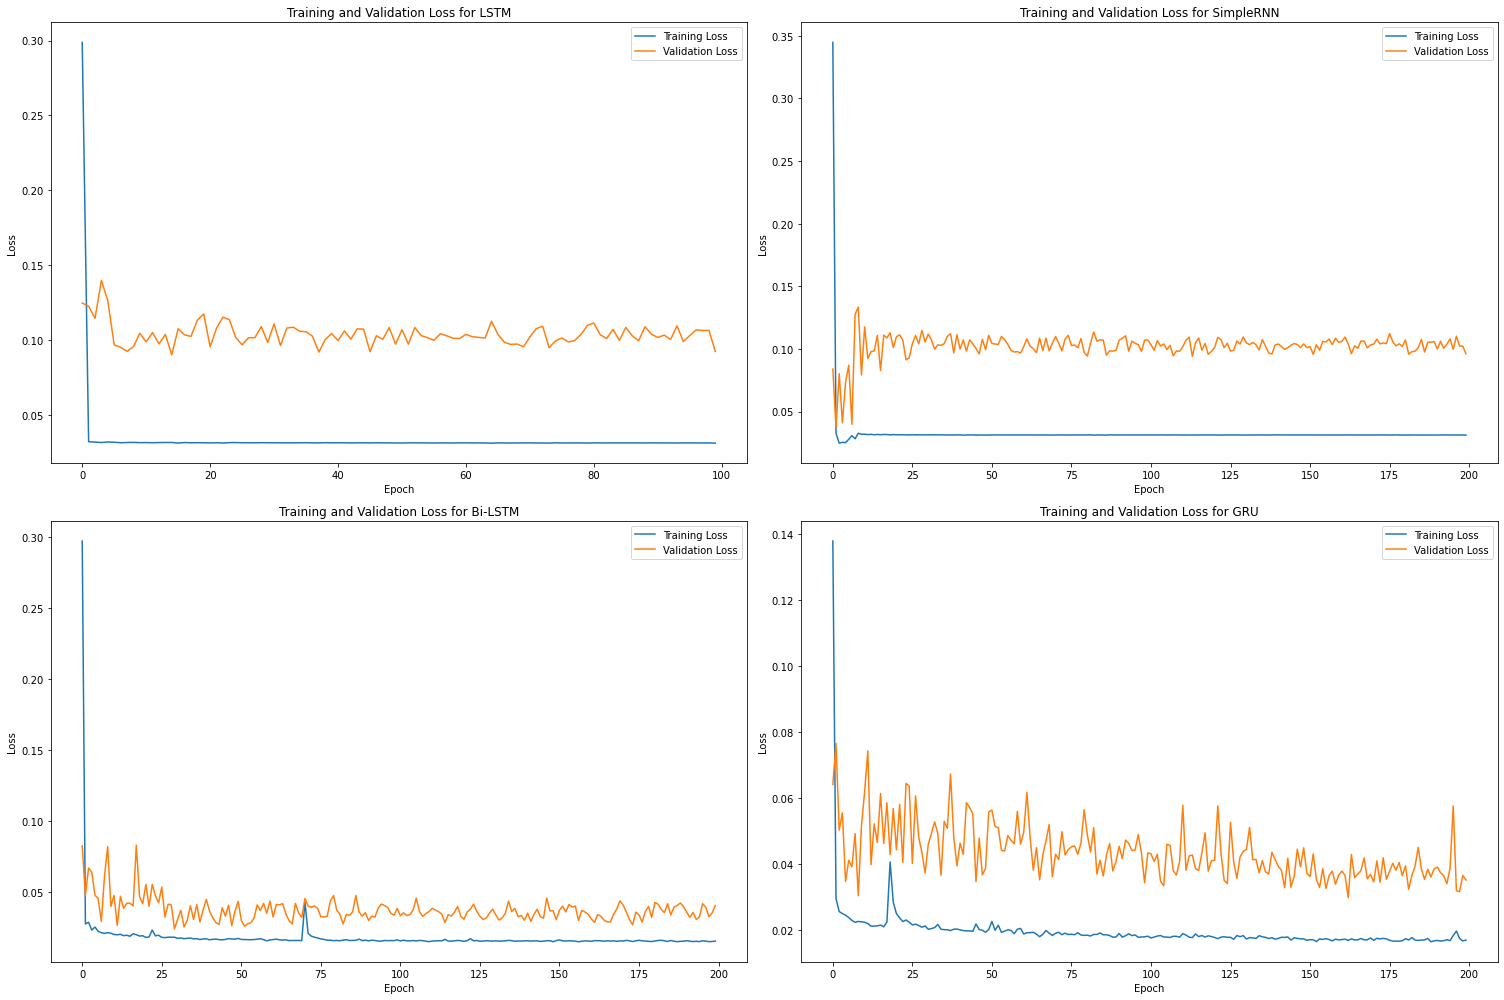

In [19]:
def plot_loss(history, model_name, ax):
    ax.plot(history.history['loss'], label='Training Loss')
    ax.plot(history.history['val_loss'], label='Validation Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training and Validation Loss for ' + model_name)
    ax.legend()

    

fig, axes = plt.subplots(2, 2, figsize=(21, 14))
axes = axes.flatten()
histories = []
model_names = ['LSTM', 'SimpleRNN', 'Bi-LSTM', 'GRU']
histories.extend([lstm_history, simple_rnn_history, bi_lstm_history, gru_history])
for i, (history, model_name) in enumerate(zip(histories, model_names)):
    plot_loss(history, model_name, axes[i])
# Hide empty subplots
for i in range(len(histories), len(axes)):
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [12]:
# from tensorflow.keras.models import load_model

# # Load each model, passing the custom RMSE function
# lstm = load_model('../model_saves/paper_method/daily_lstm_model.h5', custom_objects={'root_mean_squared_error': root_mean_squared_error})
# simple_rnn = load_model('../model_saves/paper_method/daily_simple_rnn_model.h5', custom_objects={'root_mean_squared_error': root_mean_squared_error})
# bi_lstm = load_model('../model_saves/paper_method/daily_bi_lstm_model.h5', custom_objects={'root_mean_squared_error': root_mean_squared_error})
# gru = load_model('../model_saves/paper_method/daily_gru_model.h5', custom_objects={'root_mean_squared_error': root_mean_squared_error})

In [13]:
##     Evaluate the Models in scaled data
def evaluate_model(model, model_name, X_train, Y_train, X_val, Y_val, X_test, Y_test):
    train_eval = model.evaluate(X_train, Y_train, verbose=0)
    val_eval = model.evaluate(X_val, Y_val, verbose=0)
    test_eval = model.evaluate(X_test, Y_test, verbose=0)
    print(f'\nEvaluation metrics for {model_name} model:\n-------------------')
    print('Training Data - Loss: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}'.format(train_eval[0], train_eval[1], train_eval[2]))
    print('Validation Data - Loss: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}'.format(val_eval[0], val_eval[1], val_eval[2]))
    print('Test Data - Loss: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}'.format(test_eval[0], test_eval[1], test_eval[2]),'\n')
    # print(model.metrics_names)

##     Evaluate the Models in scaled data
evaluate_model(lstm, 'LSTM',X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)
evaluate_model(simple_rnn, 'RNN',X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)
evaluate_model(bi_lstm, 'Bi-LSTM',X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)
evaluate_model(gru, 'GRU',X_train_scaled, Y_train_scaled, X_val_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)


Evaluation metrics for LSTM model:
-------------------
Training Data - Loss: 0.0316, MAE: 0.1484, RMSE: 0.1719
Validation Data - Loss: 0.0924, MAE: 0.2615, RMSE: 0.3004
Test Data - Loss: 0.3638, MAE: 0.5679, RMSE: 0.6155 


Evaluation metrics for RNN model:
-------------------
Training Data - Loss: 0.0314, MAE: 0.1470, RMSE: 0.1707
Validation Data - Loss: 0.0961, MAE: 0.2679, RMSE: 0.3063
Test Data - Loss: 0.3723, MAE: 0.5754, RMSE: 0.6226 


Evaluation metrics for Bi-LSTM model:
-------------------
Training Data - Loss: 0.0147, MAE: 0.0892, RMSE: 0.1105
Validation Data - Loss: 0.0405, MAE: 0.1548, RMSE: 0.1978
Test Data - Loss: 0.2109, MAE: 0.4113, RMSE: 0.4682 


Evaluation metrics for GRU model:
-------------------
Training Data - Loss: 0.0165, MAE: 0.0934, RMSE: 0.1142
Validation Data - Loss: 0.0353, MAE: 0.1415, RMSE: 0.1821
Test Data - Loss: 0.1824, MAE: 0.3763, RMSE: 0.4351 



In [15]:
def evaluate_predictions_model(model, model_name, X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled):
    # Predictions on training data
    y_pred_train = model.predict(X_train_scaled)
    inversed_y_pred_train = scaler.inverse_transform(np.concatenate([y_pred_train, np.zeros((y_pred_train.shape[0], scaler.n_features_in_-1))], axis=1))
    inversed_y_pred_train = inversed_y_pred_train[:, 0]

    # Predictions on validation data
    y_pred_val = model.predict(X_val_scaled)
    inversed_y_pred_val = scaler.inverse_transform(np.concatenate([y_pred_val, np.zeros((y_pred_val.shape[0], scaler.n_features_in_-1))], axis=1))
    inversed_y_pred_val = inversed_y_pred_val[:, 0]

    # Predictions on test data
    y_pred_test = model.predict(X_test_scaled)
    inversed_y_pred_test = scaler.inverse_transform(np.concatenate([y_pred_test, np.zeros((y_pred_test.shape[0], scaler.n_features_in_-1))], axis=1))
    inversed_y_pred_test = inversed_y_pred_test[:, 0]


    # Metrics on training data
    train_rmse = calculate_rmse(Y_train, inversed_y_pred_train)
    train_mae = calculate_mae(Y_train, inversed_y_pred_train)

    # Metrics on validation data
    val_rmse = calculate_rmse(Y_val, inversed_y_pred_val)
    val_mae = calculate_mae(Y_val, inversed_y_pred_val)

    # Metrics on test data
    test_rmse = calculate_rmse(Y_test, inversed_y_pred_test)
    test_mae = calculate_mae(Y_test, inversed_y_pred_test)
    
    # Print the results
    print(f"\n\nEvaluation metrics for {model_name} model:\n-------------------")
    # print('Train Dataset:')
    print(f"Train RMSE: {train_rmse:.2f} // {calculate_rmse(Y_train_scaled, y_pred_train)}")
    print(f"Train MAE: {train_mae:.2f} // {calculate_mae(Y_train_scaled, y_pred_train)}\n-------------------")

    # print('Validation Dataset:')
    print(f"Validation RMSE: {val_rmse:.2f} // {calculate_rmse(Y_val_scaled, y_pred_val)}")
    print(f"Validation MAE: {val_mae:.2f} // {calculate_mae(Y_val_scaled, y_pred_val)}\n-------------------")
    
    # print('Test Dataset:')
    print(f"Test RMSE: {test_rmse:.2f} // {calculate_rmse(Y_test_scaled, y_pred_test)}")
    print(f"Test MAE: {test_mae:.2f} // {calculate_mae(Y_test_scaled, y_pred_test)}\n\n")

    #return inversed_y_pred_train, inversed_y_pred_val, inversed_y_pred_test


evaluate_predictions_model(lstm, 'LSTM', X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, output_scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled)
evaluate_predictions_model(simple_rnn, 'RNN', X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, output_scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled)
evaluate_predictions_model(bi_lstm, 'Bi-LSTM', X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, output_scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled)
evaluate_predictions_model(gru, 'GRU', X_train_scaled, Y_train, X_val_scaled, Y_val, X_test_scaled, Y_test, output_scaler, Y_train_scaled, Y_val_scaled, Y_test_scaled)

5/5 [==============================] - 0s 48ms/step


Evaluation metrics for LSTM model:
-------------------
Train RMSE: 90.10 // 0.17785323931583236
Train MAE: 75.18 // 0.14839902177001585
-------------------
Validation RMSE: 153.98 // 0.3039363704714335
Validation MAE: 132.49 // 0.261505999258106
-------------------
Test RMSE: 305.57 // 0.6031506068718687
Test MAE: 287.73 // 0.5679426371822949


5/5 [==============================] - 0s 9ms/step


Evaluation metrics for RNN model:
-------------------
Train RMSE: 89.74 // 0.1771326130867802
Train MAE: 74.50 // 0.14704916683199537
-------------------
Validation RMSE: 157.06 // 0.3100124044828109
Validation MAE: 135.72 // 0.2678998848763392
-------------------
Test RMSE: 309.13 // 0.6101732819893602
Test MAE: 291.51 // 0.5753951847324963


5/5 [==============================] - 0s 26ms/step


Evaluation metrics for Bi-LSTM model:
-------------------
Train RMSE: 58.43 // 0.11533816761363028
Train MAE: 45.21 // 0.08924065195401273
-------